In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [4]:
df.shape

(1000, 10)

In [3]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


In [7]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
corr_matrix

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
Daily Time Spent on Site,1.000000,-0.331513,0.310954,0.518658,-0.018951,-0.748117
Age,-0.331513,1.000000,-0.182605,-0.367209,-0.021044,0.492531
Area Income,0.310954,-0.182605,1.000000,0.337496,0.001322,-0.476255
Daily Internet Usage,0.518658,-0.367209,0.337496,1.000000,0.028012,-0.786539
Male,-0.018951,-0.021044,0.001322,0.028012,1.000000,-0.038027
Clicked on Ad,-0.748117,0.492531,-0.476255,-0.786539,-0.038027,1.000000


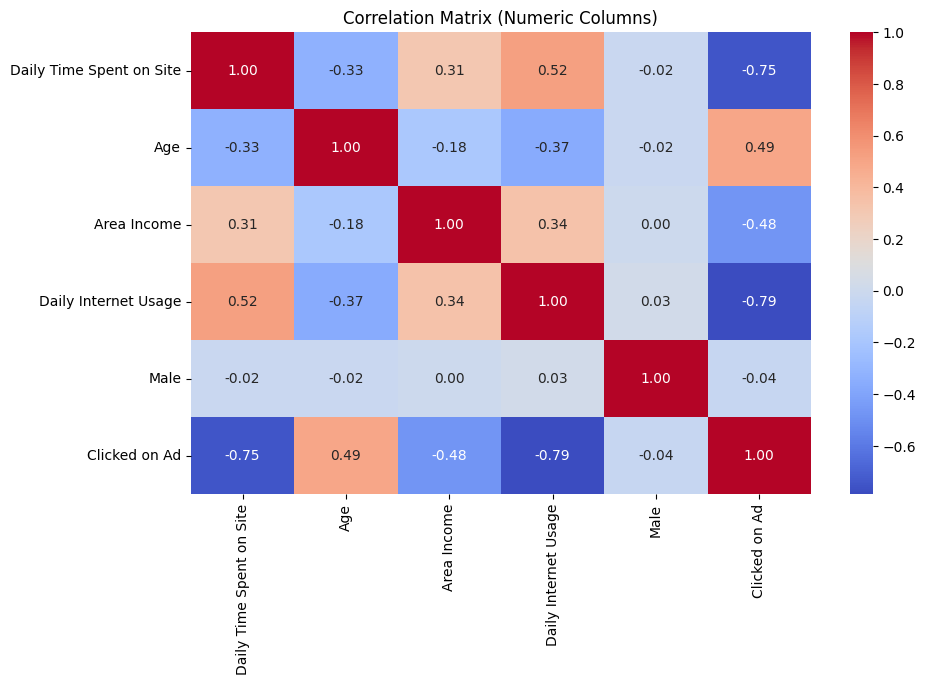

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap (only numeric columns)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Columns)")
plt.show()

Logistic Regression Model

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [10]:
X = df[['Daily Time Spent on Site', 'Daily Internet Usage']]
y = df['Clicked on Ad']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(f"Logistic Regression-Training set score: {log_reg.score(X_train, y_train):.2f}")
print(f"Logistic Regression-Test set score: {log_reg.score(X_test, y_test):.2f}")

Logistic Regression-Training set score: 0.95
Logistic Regression-Test set score: 0.93


In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score

# Create polynomial features (degree=20 to force underfitting)
poly = PolynomialFeatures(degree=20, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

underfit_model = LogisticRegression()
underfit_model.fit(X_train_poly, y_train)

print("=== Undefit Model ===")
print(f"Train Accuracy: {accuracy_score(y_train, underfit_model.predict(X_train_poly)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, underfit_model.predict(X_test_poly)):.4f}")

=== Undefit Model ===
Train Accuracy: 0.5138
Test Accuracy: 0.4450


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Create polynomial features (degree=8 for overfitting)
poly = PolynomialFeatures(degree=8, include_bias=False)
X_poly = poly.fit_transform(X)

# Split into train/test (smaller train set to force overfitting)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.7, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

overfit_model = LogisticRegression(max_iter=10000)
overfit_model.fit(X_scaled, y_train_poly)

# Evaluate
print("=== Overfit Model ===")
print(f"Train Accuracy: {overfit_model.score(X_scaled, y_train_poly):.2f}")
print(f"Test Accuracy: {overfit_model.score(X_test_scaled, y_test_poly):.2f}")

=== Overfit Model ===
Train Accuracy: 0.97
Test Accuracy: 0.94


In [15]:
from sklearn.linear_model import Ridge

In [16]:
ridge = Ridge(alpha=0.3).fit(X_scaled, y_train_poly)
print(f"Ridge Regression-Training set score: {ridge.score(X_scaled, y_train_poly):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test_scaled, y_test_poly):.2f}")

Ridge Regression-Training set score: 0.85
Ridge Regression-Test set score: 0.82


Although the training set score of ridge regression is slightly lower than the logistic regression training score, the test set score of ridge is significantly higher than the logistic regression test set score. These scores confirm that ridge regression reduces the model's complexity, leading to a less-overfit-but-more-general model.

The alpha parameter specifies a trade-off between the model's performance on the training set and its simplicity. So, increasing the alpha value (its default value is 1.0) simplifies the model by shrinking the coefficients.

In [17]:
from sklearn.model_selection import validation_curve

In [18]:
validation_curve?

In [19]:
param_range = np.logspace(-4, 4, 20)  # Test C from 0.0001 to 10000 (log scale)
param_range

array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])

In [21]:
train_scores, test_scores = validation_curve(
    estimator=LogisticRegression(penalty='l2', solver='liblinear', max_iter=10000, random_state=42),
    X=X_scaled,
    y=y_train_poly,
    param_name="C",     # LogisticRegression uses 'C', not 'alpha'
    param_range=param_range,
    scoring="accuracy"
)

                                ##        or      ##
#Ridge() (linear regression) outputs continuous values so if you have a linear regression model use estimator
#        Ridge() or Lasso() with the wanted scoring ('r2', 'mse', etc..)
#train_scores, test_scores = validation_curve(
#    estimator=Ridge(),         #While using ridge as an estimator then your parameter name will be 'alpha'
#    X=X_train,
#    y=y_train,
#    param_name="alpha",
#    param_range=param_range,
#    scoring='r2'
#)

In [22]:
print(train_scores)
print(test_scores)

[[0.925      0.9125     0.925      0.9375     0.92083333]
 [0.925      0.9125     0.925      0.9375     0.92083333]
 [0.92916667 0.91666667 0.925      0.9375     0.92083333]
 [0.92916667 0.91666667 0.92916667 0.9375     0.925     ]
 [0.92916667 0.91666667 0.92916667 0.9375     0.925     ]
 [0.93333333 0.925      0.93333333 0.94166667 0.92916667]
 [0.94166667 0.9375     0.9375     0.94583333 0.94166667]
 [0.94166667 0.9375     0.95       0.95416667 0.94583333]
 [0.95       0.95833333 0.95       0.9625     0.95416667]
 [0.9625     0.975      0.97083333 0.96666667 0.96666667]
 [0.96666667 0.975      0.97083333 0.97916667 0.96666667]
 [0.96666667 0.975      0.97083333 0.98333333 0.97083333]
 [0.96666667 0.975      0.975      0.97916667 0.97083333]
 [0.96666667 0.97083333 0.97083333 0.97916667 0.97083333]
 [0.96666667 0.97083333 0.97083333 0.975      0.97083333]
 [0.96666667 0.97083333 0.97083333 0.975      0.97083333]
 [0.96666667 0.96666667 0.97083333 0.975      0.96666667]
 [0.96666667 0

In [23]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

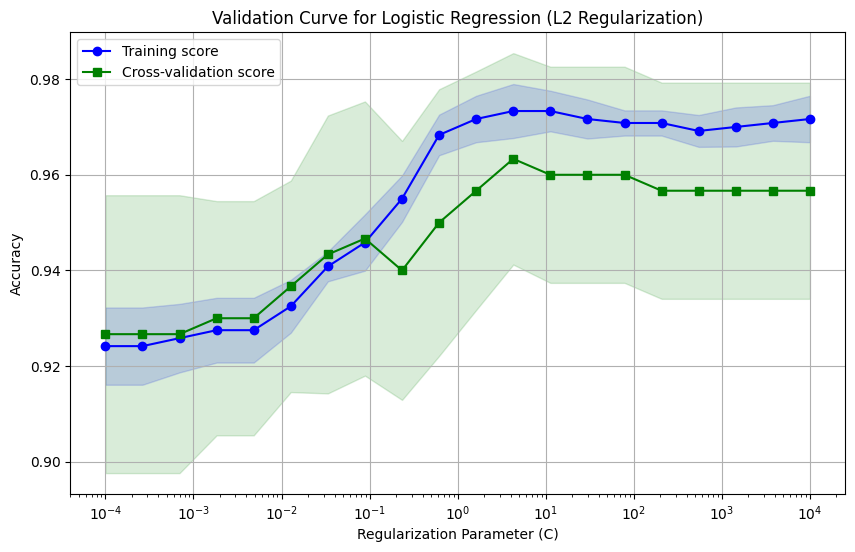

In [24]:
# Plot the validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Training score", color="blue", marker="o")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="green", marker="s")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.title("Validation Curve for Logistic Regression (L2 Regularization)")
plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [25]:
train_mean = np.mean(train_scores, axis = 1)

In [26]:
test_mean = np.mean(test_scores, axis = 1)

In [27]:
max(test_mean)

np.float64(0.9633333333333333)

In [28]:
#Find lambda function
np.where(test_mean == max(test_mean)) # Return the index
#(array([11]),)
C_value = param_range[11]
C_value
#np.float64(4.281332398719396)
best_model = LogisticRegression(
    penalty='l2',
    C=C_value
    )
best_model.fit(X_scaled, y_train_poly)

LogisticRegression(C=np.float64(4.281332398719396))

In [29]:
# Evaluate
print(f"Train Accuracy: {best_model.score(X_scaled, y_train_poly):.2f}")
print(f"Test Accuracy: {best_model.score(X_test_scaled, y_test_poly):.2f}")

Train Accuracy: 0.97
Test Accuracy: 0.94


Using GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for C (logarithmic range)
param_grid = {'C': np.logspace(-4, 4, 20)}

grid_search = GridSearchCV(
    estimator=LogisticRegression(penalty='l2', solver='liblinear'),
    param_grid=param_grid,
    scoring='accuracy'
)

grid_search.fit(X_scaled, y_train_poly)

# Results
print(f"Best C: {grid_search.best_params_['C']:.4f}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best C: 4.2813
Best CV Accuracy: 0.9633


You can complete and use Validation curve or GridsearchCV in your own using Lasso

Note: Rigde() and Lasso() are only for linear regression model if you want to use regularization for Logistic regression models then pass penalty and C values as a parameters to the model

The liblinear and lbfgs solvers are optimization algorithms.

How to Choose the Solver?
Need L1 regularization? → Use liblinear. *Large dataset? → Use lbfgs (or saga for L1+L2 on large data).
Multiclass problem? → Prefer lbfgs or saga for efficiency.